In [1]:
from spin_lattices import SpinLattice, KagomeLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from pathlib import Path
from vmc_amplitude import (
    apply_off_diag_to_basis_states,
    apply_diag_to_basis_states,
    LogProbDenseNet,
    LogProbDenseNetPairwiseXor,
    find_nbd,
    safe_exp_numpy,
    transfer_signs_to_H,
    true_relsigns,
    almost_true_relsigns,
    compute_log_local_energies,
)
from scipy.sparse import csr_matrix, diags, eye
import numpy as np
from scipy.sparse.linalg import eigsh
import lattice_symmetries as ls
import numpy.typing as npt
from typing import Callable
from nqs_playground_helpers import sample_exactly, SamplingOptions
import torch
from torch import nn
from my_stopwatch import stopwatch
from loguru import logger
import sys
from misc_utils import torch_overlap as overlap, differentiable_safe_exp
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from itertools import product
from swo import generate_training_set, generate_training_set_lanczos
import itertools

2023-09-09 17:59:13.204 | DEBUG    | lattice_symmetries:__init__:50 - Initializing Haskell runtime...
2023-09-09 17:59:13.206 | DEBUG    | lattice_symmetries:__init__:52 - Initializing Chapel runtime...
2023-09-09 17:59:13.273 | DEBUG    | lattice_symmetries:__init__:54 - Setting Python exception handler...
set_python_exception_handler ...


In [2]:
logger.remove()
logger.add(sink=sys.stderr, level="INFO")

1

In [3]:
n_samples = 5000
test_samples = 10000
power_iterations = 50
lr = 1e-3
energy_baseline = 50.0
n_hidden = 512
batch_size = 64

lattice = KagomeLattice(2, 3)
system = HeisenbergJ1J2(lattice, J2=1, use_symmetries=False, spin_inversion=None)
system.get_eigenstates(1)

stopwatch.reset()


true_amplitudes = torch.from_numpy(
    np.abs(system.get_ground_state_coeffs(system.basis.states))
).float()

df_list = []
net = "simple"
for (mode, epochs), run in product(
    [("power", 100), ("power", 1000), ("lanczos", 100), ("lanczos", 1000)], range(1)
):
    logger.info(f"Running {mode=} with {epochs=} for run {run}")
    if net == "simple":
        log_prob_fn = LogProbDenseNet(system, n_hidden=n_hidden)
    elif net == "xor":
        pairs = tuple(map(np.array, zip(*itertools.combinations(range(system.number_spins), 2))))
        log_prob_fn = LogProbDenseNetPairwiseXor(system, n_hidden=n_hidden, xor_pairs=pairs)
    else:
        raise ValueError(f"Unknown net {net}")

    optimizer = torch.optim.Adam(log_prob_fn.parameters(), lr=lr)
    criterion = torch.nn.MSELoss()

    for iteration in range(power_iterations):
        states, _ = sample_exactly(
            log_prob_fn,
            system.basis,
            SamplingOptions(
                number_samples=n_samples,
                number_chains=1,
                mode="exact",
                sweep_size=1,
                number_discarded=0,
            ),
            return_all_probs=False,
        )
        states = states.view(-1)
        remaining_states = np.delete(
            system.basis.states, system.basis.index(states.detach().numpy())
        )
        states_test = torch.from_numpy(
            np.random.choice(remaining_states, test_samples, replace=False).astype(np.int64)
        ).long()
        all_states = np.concatenate([states.detach().numpy(), states_test.detach().numpy()])

        if mode == "power":
            target = generate_training_set(
                hamiltonian=system.hamiltonian,
                states=states.detach().numpy(),
                log_prob_fn=lambda s: log_prob_fn(s).detach().numpy().reshape(-1),
                relsigns_fn=almost_true_relsigns(system, eps=0.0),
                energy_baseline=50.0,
            )
            alpha = None
        elif mode == "lanczos":
            target, alpha = generate_training_set_lanczos(
                hamiltonian=system.hamiltonian,
                states=states.detach().numpy(),
                log_prob_fn=lambda s: log_prob_fn(s).detach().numpy().reshape(-1),
                relsigns_fn=almost_true_relsigns(system, eps=0.0),
            )
        else:
            raise ValueError(f"Unknown mode {mode}")

        target = torch.from_numpy(target).float()

        # Create a TensorDataset from your inputs X and Y
        dataset = TensorDataset(states, target)

        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        # log_prob_fn = LogProbDenseNet(system, n_hidden=n_hidden)

        # optimizer = torch.optim.Adam(log_prob_fn.parameters(), lr=lr)

        # writer = SummaryWriter(
        #     log_dir=(
        #         f"experiments/{datetime.now().strftime('%Y_%m_%d')}_dense_xor_supervised/{datetime.now().strftime('%H_%M_%S')}"
        #         #        f"xor={xor_masks_idxs}_ch=_{channels}_{lr=}_{blocks=}"
        #     )
        # )

        initial_ground_state_overlap_full = overlap(
            torch.exp(log_prob_fn(system.basis.states).view(-1) * 0.5), true_amplitudes
        )

        initial_ground_state_overlap_train = overlap(
            torch.exp(log_prob_fn(states).view(-1) * 0.5),
            true_amplitudes[system.basis.index(states)],
        )

        initial_ground_state_overlap_test = overlap(
            torch.exp(log_prob_fn(states_test).view(-1) * 0.5),
            true_amplitudes[system.basis.index(states_test)],
        )

        target_ground_state_overlap_train = overlap(
            torch.exp(target.view(-1) * 0.5), true_amplitudes[system.basis.index(states)]
        )

        # target_ground_state_overlap_test = overlap(
        #     torch.exp(target_test.view(-1) * 0.5), true_amplitudes[system.basis.index(states_test)]
        # )

        for epoch in range(epochs):
            running_loss = 0.0
            for action_index, data in enumerate(dataloader, 0):
                # Get the inputs and move them to the specified device
                inputs, log_probs = data

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward pass
                outputs = log_prob_fn(inputs)

                # weights = torch.exp(2 * log_amplitudes)
                # weights = weights / torch.sum(weights)

                # Compute loss
                loss = criterion(
                    outputs, log_probs.view(-1, 1)
                )  # Reshape labels to match output shape
                # loss = 1 - overlap(
                #     differentiable_safe_exp(outputs.view(-1) * 0.5),
                #     differentiable_safe_exp(log_probs * 0.5),
                # )
                # Backward pass and optimize
                loss.backward()
                optimizer.step()

                # Collect loss
                running_loss += loss.item()

        new_ground_state_overlap_full = overlap(
            torch.exp(log_prob_fn(system.basis.states).view(-1) * 0.5), true_amplitudes
        )

        new_ground_state_overlap_train = overlap(
            torch.exp(log_prob_fn(states).view(-1) * 0.5),
            true_amplitudes[system.basis.index(states)],
        )

        new_ground_state_overlap_test = overlap(
            torch.exp(log_prob_fn(states_test).view(-1) * 0.5),
            true_amplitudes[system.basis.index(states_test)],
        )

        df_list.append(
            {
                "iteration": iteration,
                "initial_ground_state_overlap_full": initial_ground_state_overlap_full.item(),
                "initial_ground_state_overlap_train": initial_ground_state_overlap_train.item(),
                "initial_ground_state_overlap_test": initial_ground_state_overlap_test.item(),
                "target_ground_state_overlap_train": target_ground_state_overlap_train.item(),
                #            "target_ground_state_overlap_test": target_ground_state_overlap_test.item(),
                "new_ground_state_overlap_full": new_ground_state_overlap_full.item(),
                "new_ground_state_overlap_train": new_ground_state_overlap_train.item(),
                "new_ground_state_overlap_test": new_ground_state_overlap_test.item(),
                "run": run,
                "mode": mode,
                "alpha": alpha,
                "n_samples": n_samples,
                "lattice": lattice.get_cache_id(),
                "net": net,
            }
        )

        # # Add average loss per epoch to TensorBoard
        # writer.add_scalar("Training Loss", running_loss / len(dataloader), epoch)

        # Calculate overlaps and add them to TensorBoard
        # overlap_train = overlap(
        #     torch.exp(log_prob_fn(states).view(-1) * 0.5), torch.exp(target * 0.5)
        # )
        # logger.info(f"Overlap with target (train): {overlap_train.item()}")

        # overlap_test = overlap(
        #     torch.exp(log_prob_fn(states_test).view(-1) * 0.5),
        #     torch.exp(target_test * 0.5),
        # )
        # logger.info(f"Overlap with target (test): {overlap_test.item()}")

        # writer.add_scalar("train/overlap", overlap_train, epoch)
        # # writer.add_scalar('Overlap Test', overlap_test, epoch)
        # writer.add_scalar("test/overlap", overlap_test, epoch)

        logger.info(
            f"{iteration}. Full overlap with ground truth: {new_ground_state_overlap_full.item()}"
        )
        # print("Finished Training")

[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-09-09 18:01:48.347 | INFO     | __main__:<module>:25 - Running mode='power' with epochs=100 for run 0
2023-09-09 18:02:07.562 | INFO     | __main__:<module>:201 - 0. Full overlap with ground truth: 0.526570200920105
2023-09-09 18:02:26.584 | INFO     | __main__:<module>:201 - 1. Full overlap with ground truth: 0.5994749069213867
2023-09-09 18:02:45.662 | INFO     | __main__:<module>:201 - 2. Full overlap with ground truth: 0.6625240445137024
2023-09-09 18:03:04.916 | INFO     | __main__:<module>:201 - 3. Full overlap with ground truth: 0.7221819162368774
2023-09-09 18:03:23.686 | INFO     | __main__:<module>:201 - 4. Full overlap with ground truth: 0.7743629217147827
2023-09-09 18:03:42.584 | INFO     | __main__:<module>:201 - 5. Full overlap with ground truth: 0.8186426162719727
2023-09-09 18:04:01.254 | INFO     | __main__:<module>:201 - 6. Full overlap with ground truth: 0.852494478225708
2023-09-09 18:04:19.954 | INFO

KeyboardInterrupt: 

In [8]:
df = pd.DataFrame(df_list)

In [9]:
df.columns

Index(['iteration', 'initial_ground_state_overlap_full',
       'initial_ground_state_overlap_train',
       'initial_ground_state_overlap_test',
       'target_ground_state_overlap_train', 'new_ground_state_overlap_full',
       'new_ground_state_overlap_train', 'new_ground_state_overlap_test',
       'run', 'mode', 'alpha', 'n_samples', 'lattice', 'net'],
      dtype='object')

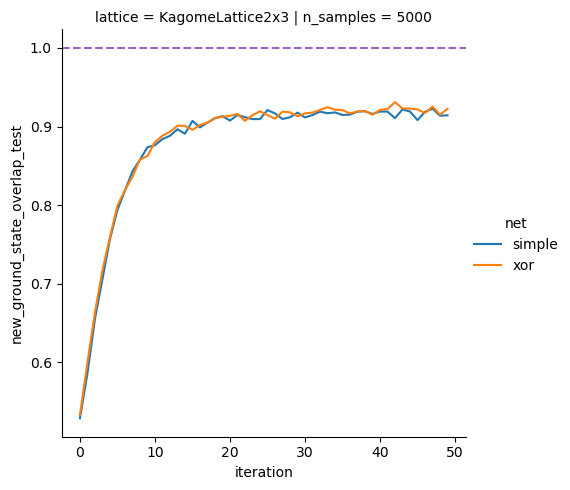

In [10]:
sns.relplot(
    df,
    x="iteration",
    y="new_ground_state_overlap_test",
    hue="net",
    kind="line",
    col="n_samples",
    row="lattice",
)
plt.axhline(1, ls='--', color='C4')

In [7]:
df.groupby('slowdown')['new_ground_state_overlap_test'].max()

KeyError: 'slowdown'

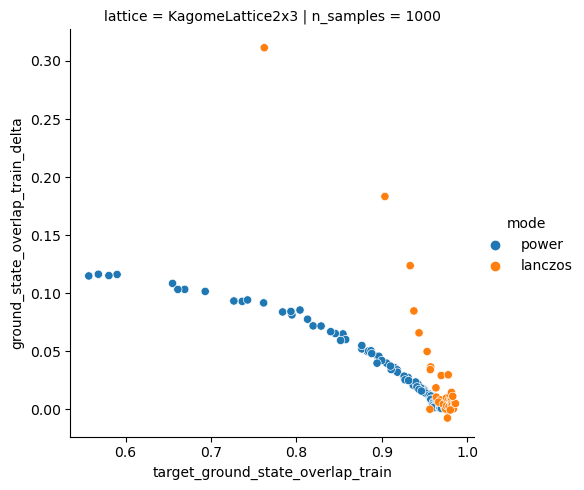

In [ ]:
sns.relplot(
    df.assign(
        ground_state_overlap_train_delta=lambda x: x["target_ground_state_overlap_train"]
        - x["initial_ground_state_overlap_train"],
    ),
    x="target_ground_state_overlap_train",
    y="ground_state_overlap_train_delta",
    hue="mode",
    # kind="line",
    col='n_samples',
    row='lattice',
)

In [ ]:
predicted_probs = torch.exp(log_prob_fn(system.basis.states).view(-1))
predicted_probs /= predicted_probs.sum()
predicted_ipr = (predicted_probs**2).sum().item()

In [ ]:
predicted_ipr

0.001416423823684454

In [ ]:
(system.get_ground_state_coeffs(system.canonical_basis.states) ** 4).sum()

0.000420467020452604

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "pandas/_libs/lib.pyx", line 2369, in pandas._libs.lib.maybe_convert_numeric
ValueError: Unable to parse string "power"

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/nix/store/hfssxajj0jlisx6szidc11ix5xfk0lww-python3-3.10.12-env/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 3460, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/nix-shell.Pu1x8R/ipykernel_2490659/3647371210.py", line 1, in <module>
    sns.relplot(
  File "/nix/store/hfssxajj0jlisx6szidc11ix5xfk0lww-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/relational.py", line 955, in relplot
    g.map_dataframe(func, **plot_kws)
  File "/nix/store/hfssxajj0jlisx6szidc11ix5xfk0lww-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py", line 819, in map_dataframe
    self._facet_plot(func, ax, args, kwargs)
  File "/nix/store/hfssxajj0jlisx6szidc1

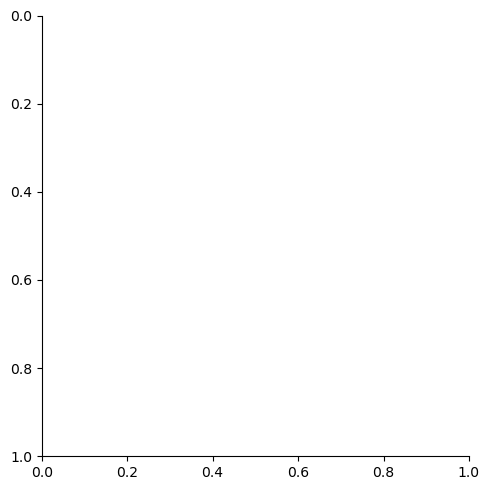

In [ ]:
sns.relplot(
    df.melt(id_vars=["iteration"]),
    x="iteration",
    y="value",
    hue="variable",
    kind="line",
    style="variable",
    dashes=False,
    markers=True,
)

In [ ]:
df

,iteration,initial_ground_state_overlap_full,initial_ground_state_overlap_train,initial_ground_state_overlap_test,target_ground_state_overlap_train,new_ground_state_overlap_full,new_ground_state_overlap_train,new_ground_state_overlap_test,run,mode,alpha,n_samples,lattice,slowdown
0,0,0.448617,0.473987,0.450390,0.590144,0.509284,0.561113,0.509146,0,power,N00000000a00000000N,1000,KagomeLattice2x3,0.0
1,1,0.509284,0.546680,0.507203,0.655131,0.576688,0.640027,0.572134,0,power,N00000000a00000000N,1000,KagomeLattice2x3,0.0
2,2,0.576688,0.643677,0.579712,0.736670,0.629849,0.727870,0.630154,0,power,N00000000a00000000N,1000,KagomeLattice2x3,0.0
3,3,0.629849,0.713490,0.625178,0.794872,0.675776,0.790396,0.669497,0,power,N00000000a00000000N,1000,KagomeLattice2x3,0.0
4,4,0.675776,0.747809,0.668600,0.819716,0.711710,0.816916,0.701798,0,power,N00000000a00000000N,1000,KagomeLattice2x3,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,45,0.658410,0.980005,0.558387,0.985141,0.656833,0.985129,0.550778,0,lanczos,-0.214542+0.000000j,1000,KagomeLattice2x3,0.0
246,46,0.656833,0.983492,0.543274,0.984086,0.653457,0.984093,0.529738,0,lanczos,-0.412041+0.000000j,1000,KagomeLattice2x3,0.0
247,47,0.653457,0.981275,0.553538,0.986377,0.656173,0.986369,0.549480,0,lanczos,-0.212217+0.000000j,1000,KagomeLattice2x3,0.0
248,48,0.656173,0.980799,0.535010,0.980351,0.645482,0.980364,0.511280,0,lanczos,-0.431103+0.000000j,1000,KagomeLattice2x3,0.0


In [ ]:
sns.relplot(
    df.query("iteration > 15")
    .assign(
        ground_state_overlap_train_delta=lambda x: x["new_ground_state_overlap_train"]
        - x["initial_ground_state_overlap_train"],
        ground_state_overlap_test_delta=lambda x: x["new_ground_state_overlap_test"]
        - x["initial_ground_state_overlap_test"],
        target_ground_state_overlap_train_delta=lambda x: x["target_ground_state_overlap_train"]
        - x["initial_ground_state_overlap_train"],
        target_ground_state_overlap_test_delta=lambda x: x["target_ground_state_overlap_test"]
        - x["initial_ground_state_overlap_test"],
    )[
        [
            "iteration",
            "ground_state_overlap_train_delta",
            "ground_state_overlap_test_delta",
            "target_ground_state_overlap_train_delta",
            "target_ground_state_overlap_test_delta",
        ]
    ]
    .melt(id_vars="iteration"),
    x="iteration",
    y="value",
    hue="variable",
    kind="line",
)
plt.axhline(0, color="black", linestyle="--")

KeyError: 'target_ground_state_overlap_test'

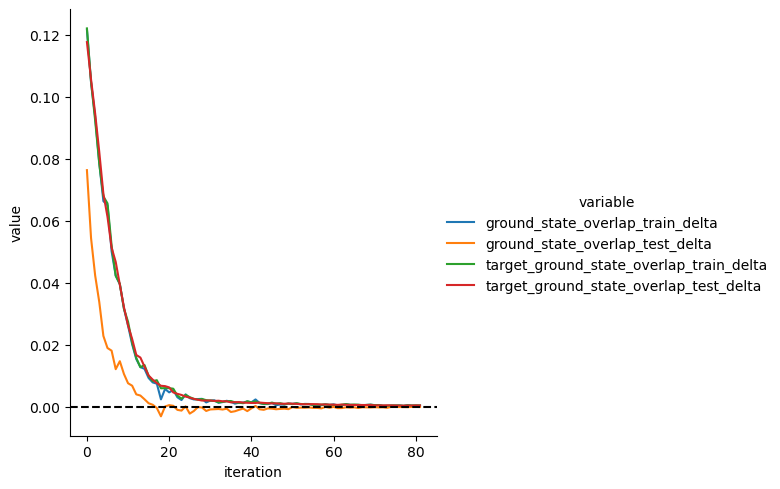

In [ ]:
sns.relplot(
    df.query("iteration > -1")
    .assign(
        ground_state_overlap_train_delta=lambda x: x["new_ground_state_overlap_train"]
        - x["initial_ground_state_overlap_train"],
        ground_state_overlap_test_delta=lambda x: x["new_ground_state_overlap_test"]
        - x["initial_ground_state_overlap_test"],
        target_ground_state_overlap_train_delta=lambda x: x["target_ground_state_overlap_train"]
        - x["initial_ground_state_overlap_train"],
        target_ground_state_overlap_test_delta=lambda x: x["target_ground_state_overlap_test"]
        - x["initial_ground_state_overlap_test"],
    )[
        [
            "iteration",
            "ground_state_overlap_train_delta",
            "ground_state_overlap_test_delta",
            "target_ground_state_overlap_train_delta",
            "target_ground_state_overlap_test_delta",
        ]
    ]
    .melt(id_vars="iteration"),
    x="iteration",
    y="value",
    hue="variable",
    kind="line",
)
plt.axhline(0, color="black", linestyle="--")

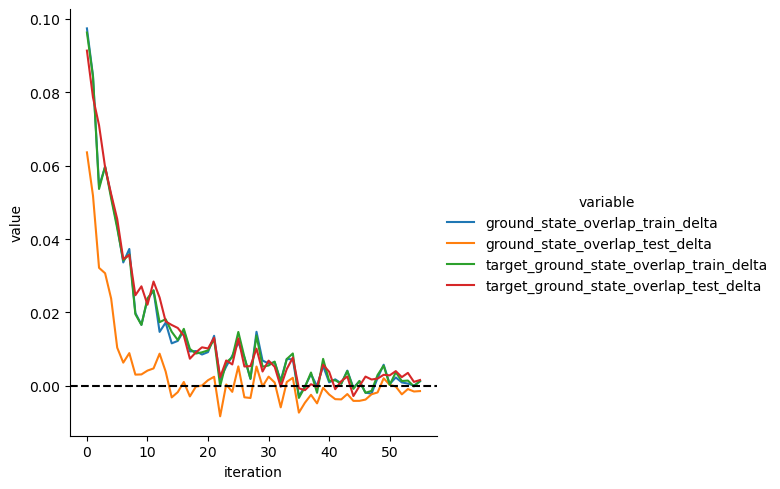

In [ ]:
sns.relplot(
    df.query("iteration > -1")
    .assign(
        ground_state_overlap_train_delta=lambda x: x["new_ground_state_overlap_train"]
        - x["initial_ground_state_overlap_train"],
        ground_state_overlap_test_delta=lambda x: x["new_ground_state_overlap_test"]
        - x["initial_ground_state_overlap_test"],
        target_ground_state_overlap_train_delta=lambda x: x["target_ground_state_overlap_train"]
        - x["initial_ground_state_overlap_train"],
        target_ground_state_overlap_test_delta=lambda x: x["target_ground_state_overlap_test"]
        - x["initial_ground_state_overlap_test"],
    )[
        [
            "iteration",
            "ground_state_overlap_train_delta",
            "ground_state_overlap_test_delta",
            "target_ground_state_overlap_train_delta",
            "target_ground_state_overlap_test_delta",
        ]
    ]
    .melt(id_vars="iteration"),
    x="iteration",
    y="value",
    hue="variable",
    kind="line",
)
plt.axhline(0, color="black", linestyle="--")

In [ ]:
def truncated_overlap(predicted_amplitudes, eigenvect, start, stop):
    sort_order = np.argsort(predicted_amplitudes)[start:stop]
    return overlap_numpy(predicted_amplitudes[sort_order], eigenvect[sort_order])

In [ ]:
for i, (eigenval, eigenvect) in enumerate(zip(eigenvals, eigenvects.T)):
    print(
        f"{i}. "
        f"{eigenval=}, {overlap_numpy(predicted_amplitudes, eigenvect)=:.3f}, "
        f"{overlap_numpy(predicted_amplitudes, eigenvect)=:.3f}"
    )

0. eigenval=80.41087417918975, overlap_numpy(predicted_amplitudes, eigenvect)=-0.002, overlap_numpy(predicted_amplitudes, eigenvect)=-0.002
1. eigenval=80.4108741791902, overlap_numpy(predicted_amplitudes, eigenvect)=-0.001, overlap_numpy(predicted_amplitudes, eigenvect)=-0.001
2. eigenval=80.41087417919039, overlap_numpy(predicted_amplitudes, eigenvect)=0.002, overlap_numpy(predicted_amplitudes, eigenvect)=0.002
3. eigenval=80.43272389333097, overlap_numpy(predicted_amplitudes, eigenvect)=0.002, overlap_numpy(predicted_amplitudes, eigenvect)=0.002
4. eigenval=80.43272389333187, overlap_numpy(predicted_amplitudes, eigenvect)=-0.002, overlap_numpy(predicted_amplitudes, eigenvect)=-0.002
5. eigenval=80.4327238933319, overlap_numpy(predicted_amplitudes, eigenvect)=0.001, overlap_numpy(predicted_amplitudes, eigenvect)=0.001
6. eigenval=80.54832191409514, overlap_numpy(predicted_amplitudes, eigenvect)=-0.005, overlap_numpy(predicted_amplitudes, eigenvect)=-0.005
7. eigenval=80.5483219140952

In [ ]:
0.7**2 + 0.6**2 + 0.2**2

0.8899999999999999

In [ ]:
q = eigenvects[:, 39] * 0.5 + eigenvects[:, 32] * 0.5

In [ ]:
overlap_numpy(M_with_signs @ q, q)

0.9999969910552985

In [ ]:
def plot_distance(predicted_amplitudes, eigenvect, window=100, label=""):
    sort_order = np.argsort(-predicted_amplitudes)
    plt.plot(
        [
            truncated_overlap(predicted_amplitudes, eigenvect, i, i + window)
            for i in range(0, len(predicted_amplitudes) - window, window)
        ],
        label=label,
    )
    # plt.plot(predicted_amplitudes[sort_order])

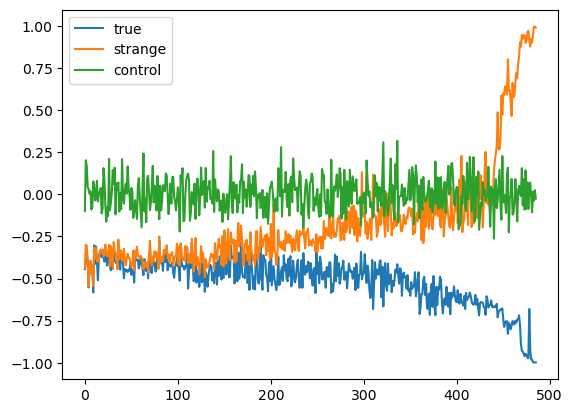

In [ ]:
plot_distance(predicted_amplitudes, eigenvects[:, 39], label="true")
plot_distance(predicted_amplitudes, eigenvects[:, 32], label="strange")
plot_distance(predicted_amplitudes, eigenvects[:, 30], label="control")
plt.legend()

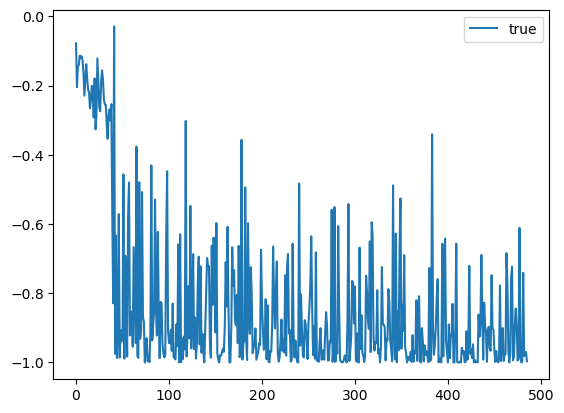

In [ ]:
plot_distance(np.abs(eigenvects[:, 32]), eigenvects[:, 39], label="true")
# plot_distance(predicted_amplitudes, , label='control')
plt.legend()

In [ ]:
sorted(
    [
        (np.abs(overlap_numpy(np.abs(eigenvects[:, i]), eigenvects[:, 39])), i)
        for i in range(40)
    ]
)

[(0.5080889901217034, 36),
 (0.5471087533771598, 30),
 (0.5623257939898711, 31),
 (0.5725894876497576, 29),
 (0.5804911757247583, 9),
 (0.592839207208757, 12),
 (0.5963717375207368, 14),
 (0.6024535396889609, 13),
 (0.6251684783732167, 17),
 (0.632365685561331, 1),
 (0.6369516823075597, 0),
 (0.6414597021746236, 15),
 (0.6415077806425101, 16),
 (0.6417120372303068, 2),
 (0.6417238122422682, 21),
 (0.6461697251595383, 20),
 (0.6462690211156571, 22),
 (0.6509254915192184, 10),
 (0.6539411861771934, 23),
 (0.6611026979222373, 24),
 (0.664925506061529, 35),
 (0.6669639552064476, 25),
 (0.6765987782441611, 3),
 (0.6767867854187702, 28),
 (0.6770057470168648, 4),
 (0.6784761569228384, 5),
 (0.6794453595965398, 19),
 (0.6808317351595014, 26),
 (0.6825699949821143, 27),
 (0.6848847834407994, 18),
 (0.6935149636639522, 33),
 (0.693947473514594, 38),
 (0.6989476891260374, 37),
 (0.7101069338583741, 34),
 (0.7448502432393513, 11),
 (0.7991075830941066, 8),
 (0.7997744186812201, 6),
 (0.8005954128